Using device: cuda



  0%|          | 0/50 [00:00<?, ?it/s]


  2%|▏         | 1/50 [00:01<00:50,  1.03s/it]


  4%|▍         | 2/50 [00:01<00:32,  1.50it/s]


  6%|▌         | 3/50 [00:02<00:29,  1.60it/s]

...


 96%|█████████▌| 48/50 [00:29<00:01,  1.57it/s]


 98%|█████████▊| 49/50 [00:30<00:00,  1.57it/s]


100%|██████████| 50/50 [00:30<00:00,  1.56it/s]


100%|██████████| 50/50 [00:30<00:00,  1.62it/s]

Saved image to /content/reifusion/images/generated.png


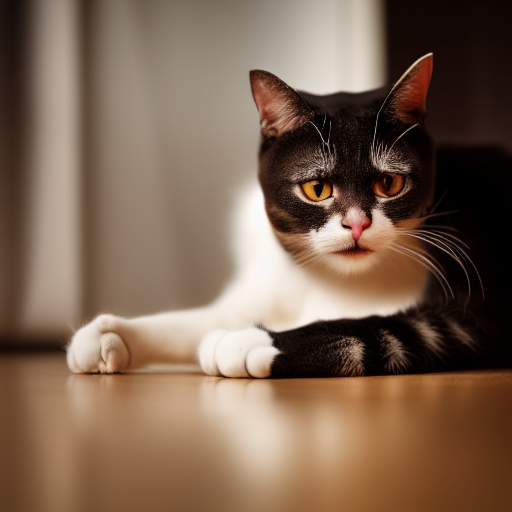

In [1]:
import sys
import inspect
from PIL import Image
from pathlib import Path
from huggingface_hub import hf_hub_download
from transformers import CLIPTokenizer
import torch

repo_candidates = (Path.cwd(), Path.cwd().parent, Path("/content/reifusion"))
REPO_ROOT = next(path for path in repo_candidates if (path / "model" / "pipeline.py").exists())
sys.path.insert(0, str(REPO_ROOT))

from model import model_loader, pipeline

DEVICE = "cpu"

ALLOW_CUDA = True
ALLOW_MPS = False

if torch.cuda.is_available() and ALLOW_CUDA:
    DEVICE = "cuda"
elif torch.backends.mps.is_available() and ALLOW_MPS:
    DEVICE = "mps"
print(f"Using device: {DEVICE}")

data_dir = REPO_ROOT / "data"
tokenizer_paths = {
    "vocab": str(data_dir / "vocab.json"),
    "merges": str(data_dir / "merges.txt"),
}
tokenizer_params = inspect.signature(CLIPTokenizer.__init__).parameters
if "vocab" in tokenizer_params:
    tokenizer = CLIPTokenizer(**tokenizer_paths)
else:
    tokenizer = CLIPTokenizer(
        vocab_file=tokenizer_paths["vocab"],
        merges_file=tokenizer_paths["merges"],
    )
model_file = data_dir / "v1-5-pruned-emaonly.safetensors"
if not model_file.exists():
    hf_hub_download(
        repo_id="stable-diffusion-v1-5/stable-diffusion-v1-5",
        filename=model_file.name,
        local_dir=data_dir,
    )
models = model_loader.preload_models_from_standard_weights(model_file, DEVICE)

## TEXT TO IMAGE

# prompt = "A dog with sunglasses, wearing comfy hat, looking at camera, highly detailed, ultra sharp, cinematic, 100mm lens, 8k resolution."
prompt = "A cat stretching on the floor, highly detailed, ultra sharp, cinematic, 100mm lens, 8k resolution."
uncond_prompt = ""  # Also known as negative prompt
do_cfg = True
cfg_scale = 8  # min: 1, max: 14

## IMAGE TO IMAGE

input_image = None
# Comment to disable image to image
# image_path = "../images/dog.jpg"
# input_image = Image.open(image_path)
# Higher values means more noise will be added to the input image, so the result will further from the input image.
# Lower values means less noise is added to the input image, so output will be closer to the input image.
strength = 0.9

## SAMPLER

sampler = "ddpm"
num_inference_steps = 50
seed = 42

output_image = pipeline.generate(
    prompt=prompt,
    uncond_prompt=uncond_prompt,
    input_image=input_image,
    strength=strength,
    do_cfg=do_cfg,
    cfg_scale=cfg_scale,
    sampler_name=sampler,
    n_inference_steps=num_inference_steps,
    seed=seed,
    models=models,
    device=DEVICE,
    idle_device="cpu",
    tokenizer=tokenizer,
)

result = Image.fromarray(output_image)
output_path = REPO_ROOT / "images" / "generated.png"
output_path.parent.mkdir(parents=True, exist_ok=True)
result.save(output_path)
print(f"Saved image to {output_path}")
result